In [15]:
#SVM
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

df=pd.read_csv("iris1.csv")
print(df.head(10))
array=df.values
X=array[:,0:4]
y=array[:,4]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)
model=SVC(kernel='linear',random_state=0)
model.fit(X_train,y_train)
pred=model.predict(X_test)
print("\n\nThe confusion matrix is\n\n")
conf=confusion_matrix(y_test,pred)
print(conf)
print("\n\nAccuracy is")
accuracy=accuracy_score(y_test,pred)
print(accuracy)
print("\nClassification Report")
report=classification_report(y_test,pred)
print(report)
model1=SVC(kernel='rbf',random_state=0)
model1.fit(X_train,y_train)
pred=model1.predict(X_test)
print("\n\nThe confusion matrix for RBF kernel is\n\n")
conf=confusion_matrix(y_test,pred)
print(conf)
print("\n\nAccuracy for RBF kernel is")
accuracy=accuracy_score(y_test,pred)
print(accuracy)

   SepalLength  SepalWidth  PetalLength  PetalWidth Species
0          5.1         3.5          1.4         0.2  setosa
1          4.9         3.0          1.4         0.2  setosa
2          4.7         3.2          1.3         0.2  setosa
3          4.6         3.1          1.5         0.2  setosa
4          5.0         3.6          1.4         0.2  setosa
5          5.4         3.9          1.7         0.4  setosa
6          4.6         3.4          1.4         0.3  setosa
7          5.0         3.4          1.5         0.2  setosa
8          4.4         2.9          1.4         0.2  setosa
9          4.9         3.1          1.5         0.1  setosa


The confusion matrix is


[[1 0 0]
 [0 2 0]
 [0 1 2]]


Accuracy is
0.8333333333333334

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         1
  versicolor       0.67      1.00      0.80         2
   virginica       1.00      0.67      0.80         3

    accura

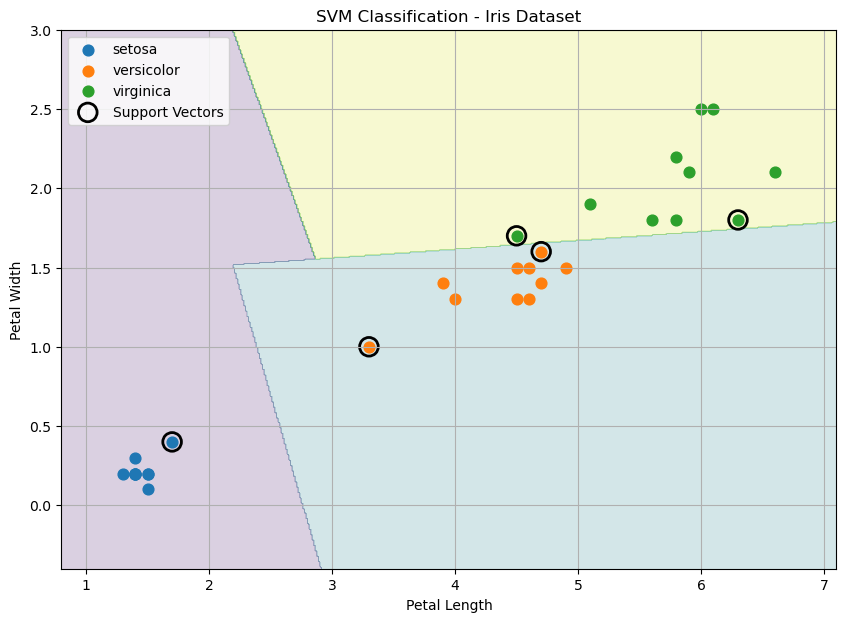

In [14]:
#SVM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

df=pd.read_csv("iris1.csv")

X=df.iloc[:,2:4].values
y=df.iloc[:,4].values

model=SVC(kernel='linear',C=1000)
model.fit(X,y)

x_min=X[:,0].min()-0.5
x_max=X[:,0].max()+0.5
y_min=X[:,1].min()-0.5
y_max=X[:,1].max()+0.5

xx,yy=np.meshgrid(
    np.linspace(x_min,x_max,500),
    np.linspace(y_min,y_max,500)
)

Z=model.predict(np.c_[xx.ravel(),yy.ravel()])

classes=np.unique(y)
Z=np.array([np.where(classes==i)[0][0] for i in Z])
Z=Z.reshape(xx.shape)

plt.figure(figsize=(10,7))

plt.contourf(xx,yy,Z,alpha=0.2)

for species in classes:
    data=X[y==species]
    plt.scatter(
        data[:,0],
        data[:,1],
        s=60,
        label=species
    )

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("SVM Classification - Iris Dataset")
plt.legend()
plt.grid()

plt.savefig("svm_iris_graph.svg",format="svg",bbox_inches="tight")

plt.show()

# import numpy as np

n=int(input("Enter number of inputs: "))
h=int(input("Enter hidden neurons: "))
lr=float(input("Enter learning rate: "))
epochs=int(input("Enter epochs: "))

X=[]
y=[]

for i in range(n):
    X.append(list(map(float,input("Enter input: ").split())))
    y.append([float(input("Enter target: "))])

X=np.array(X)
y=np.array(y)

W1=np.random.randn(X.shape[1],h)
b1=np.zeros((1,h))
W2=np.random.randn(h,1)
b2=np.zeros((1,1))

def sigmoid(x):
    return 1/(1+np.exp(-x))

def derivative(x):
    return x*(1-x)

for i in range(epochs):
    a1=sigmoid(np.dot(X,W1)+b1)
    a2=sigmoid(np.dot(a1,W2)+b2)
    e=y-a2
    d2=e*derivative(a2)
    d1=np.dot(d2,W2.T)*derivative(a1)
    W2+=lr*np.dot(a1.T,d2)
    b2+=lr*np.sum(d2,axis=0,keepdims=True)
    W1+=lr*np.dot(X.T,d1)
    b1+=lr*np.sum(d1,axis=0,keepdims=True)

print("Output:")
print(a2)
print("Predicted:")
print((a2>=0.5).astype(int))

In [22]:
import numpy as np

n=int(input("Enter number of inputs: "))
h=int(input("Enter hidden neurons: "))
lr=float(input("Enter learning rate: "))
epochs=int(input("Enter epochs: "))

X=[]
y=[]

for i in range(n):
    X.append(list(map(float,input("Enter input: ").split())))
    y.append([float(input("Enter target: "))])

X=np.array(X)
y=np.array(y)

W1=np.random.randn(X.shape[1],h)
b1=np.zeros((1,h))
W2=np.random.randn(h,1)
b2=np.zeros((1,1))

def sigmoid(x):
    return 1/(1+np.exp(-x))

def derivative(x):
    return x*(1-x)

for i in range(epochs):
    a1=sigmoid(np.dot(X,W1)+b1)
    a2=sigmoid(np.dot(a1,W2)+b2)
    e=y-a2
    d2=e*derivative(a2)
    d1=np.dot(d2,W2.T)*derivative(a1)
    W2+=lr*np.dot(a1.T,d2)
    b2+=lr*np.sum(d2,axis=0,keepdims=True)
    W1+=lr*np.dot(X.T,d1)
    b1+=lr*np.sum(d1,axis=0,keepdims=True)

print("Output:")
print(a2)
print("Predicted:")
print((a2>=0.5).astype(int))

Enter number of inputs:  4
Enter hidden neurons:  2
Enter learning rate:  0.8
Enter epochs:  1000
Enter input:  0 0
Enter target:  0
Enter input:  0 1
Enter target:  1
Enter input:  1 0
Enter target:  1
Enter input:  1 1
Enter target:  0


Output:
[[0.04692556]
 [0.93788037]
 [0.49879415]
 [0.5070925 ]]
Predicted:
[[0]
 [1]
 [0]
 [1]]
